# Cumulative Re-Encoding Residual Compression

**Algorithm variant of Section 7 (closed-loop per-segment):**

At each step `i`, instead of encoding a single residual as an isolated file, we
re-encode the **entire accumulated sequence** `[f_0, r_1, r_2, ..., r_i]` into one
HEVC stream. This lets the codec exploit temporal correlation across all residuals
seen so far.

| Step | List content | Action |
|------|-------------|--------|
| init | `[f_0]` | normalize and add first frame |
| i=0 | `[f_0]` | encode → decode last → get f̂_0 → compute r_1 |
| i=1 | `[f_0, r_1]` | encode → decode last → get r̂_1 → f̂_1 = f̂_0 − r̂_1 → compute r_2 |
| i=k | `[f_0, r_1, …, r_k]` | encode → decode last → update f̂_k → compute r_{k+1} |

**Baseline:** direct HEVC encoding of raw frames at cq = 100 and cq = 99 (§4 quality sweep).

In [1]:
# Add project root to path
import sys
from pathlib import Path
import lovely_tensors as lt
lt.monkey_patch()

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /Users/lfbarba/GitHub/sdate to Python path


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as _skimage_ssim

from sdate.stream_hvec import HevcGray10Streamer, concat_hevc_segments
from sdate.stream_hvec.stream_gray10 import EncoderParams
from sdate.video_compression.hevc_grayscale import decode_hevc_grayscale_10bit
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
DATA_PATH = Path('../data/ct_files/file_1_extracted')
NUM_PROJECTIONS = 50
TARGET_SIZE = (2560//2, 2160//2)

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)

volume = dataset.get_full_volume()  # (H, W, D)

H, W = volume.shape[:2]
N_FRAMES = volume.shape[2]
print(f"\nVolume shape: {volume.shape}")
print(f"Image size:   {H} × {W}")
print(f"Total frames: {N_FRAMES}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
🔬 Loading dark and flat field images...


Loading flats: 100%|██████████| 100/100 [00:02<00:00, 34.65it/s]


## Alternative: Load a Natural Grayscale Video

Instead of CT projections, you can download any short video from the internet using `yt-dlp`
and extract frames as the `volume` tensor `(H, W, N_FRAMES)`.

`yt-dlp` is a widely-available, pip-installable CLI tool that works with YouTube and hundreds
of other sites.  The cell below fetches a clip, converts it to grayscale with `ffmpeg`, and
produces the same `volume`, `H`, `W`, `N_FRAMES` variables expected by the rest of the notebook.

```
pip install yt-dlp          # if not already installed
# ffmpeg must be on PATH (brew install ffmpeg / apt install ffmpeg)
```


In [26]:
import subprocess, tempfile, os
import cv2  # pip install opencv-python-headless

# ── Config ────────────────────────────────────────────────────────────────
# Any public video URL supported by yt-dlp (YouTube, Vimeo, etc.)
# Default: Big Buck Bunny (public domain, hosted on archive.org — no login needed)
YOUTUBE_URL      = "https://archive.org/download/BigBuckBunny_124/Content/big_buck_bunny_720p_surround.mp4"
YT_START_SEC     = 60.0   # start offset in seconds
YT_NUM_FRAMES    = 50     # number of frames to extract
YT_TARGET_HEIGHT = 360    # resize height (width auto-scaled); None = keep original
YT_COOKIES_FILE  = None   # path to a Netscape cookies.txt file if needed for auth
YT_COOKIES_BROWSER = None # alternatively: "chrome", "firefox", etc. (yt-dlp --cookies-from-browser)

tmpdir = tempfile.mkdtemp()
video_path = os.path.join(tmpdir, "video.mp4")

# ── Download ──────────────────────────────────────────────────────────────
import yt_dlp

ydl_opts = {
    "format": "bestvideo[ext=mp4]+bestaudio/best[ext=mp4]/best",
    "outtmpl": video_path,
    "quiet": True,
    "no_warnings": True,
}
if YT_COOKIES_FILE:
    ydl_opts["cookiefile"] = YT_COOKIES_FILE
if YT_COOKIES_BROWSER:
    ydl_opts["cookiesfrombrowser"] = (YT_COOKIES_BROWSER,)

print(f"Downloading: {YOUTUBE_URL}")
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([YOUTUBE_URL])
print(f"Saved to: {video_path}")

# ── Extract frames with OpenCV ────────────────────────────────────────────
cap = cv2.VideoCapture(video_path)
fps_src = cap.get(cv2.CAP_PROP_FPS) or 30.0
cap.set(cv2.CAP_PROP_POS_MSEC, YT_START_SEC * 1000)

frames = []
while len(frames) < YT_NUM_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # (H, W) uint8
    if YT_TARGET_HEIGHT is not None:
        scale = YT_TARGET_HEIGHT / gray.shape[0]
        new_w = int(gray.shape[1] * scale)
        gray = cv2.resize(gray, (new_w, YT_TARGET_HEIGHT), interpolation=cv2.INTER_AREA)
    frames.append(gray)
cap.release()

if len(frames) == 0:
    raise RuntimeError("No frames extracted — check the URL and YT_START_SEC offset.")

# ── Build volume tensor (H, W, N_FRAMES) ─────────────────────────────────
frames_np = np.stack(frames, axis=-1).astype(np.float32)   # (H, W, N)
volume = torch.from_numpy(frames_np)                        # float32, range [0, 255]

H, W = volume.shape[:2]
N_FRAMES = volume.shape[2]
raw_bytes_per_frame = H * W * 2  # int16 baseline (same convention as CT path)

print(f"\nVolume shape: {volume.shape}")
print(f"Image size:   {H} × {W}")
print(f"Total frames: {N_FRAMES}")
print(f"Value range:  [{volume.min():.1f}, {volume.max():.1f}]")


Deprecated Feature: Support for Python version 3.9 has been deprecated. Please update to Python 3.10 or above


Downloading: https://archive.org/download/BigBuckBunny_124/Content/big_buck_bunny_720p_surround.mp4
Saved to: /var/folders/tz/dk16058s17q23bj28chlys680000gn/T/tmpf3b_izzi/video.mp4

Volume shape: torch.Size([360, 640, 50])
Image size:   360 × 640
Total frames: 50
Value range:  [5.0, 255.0]


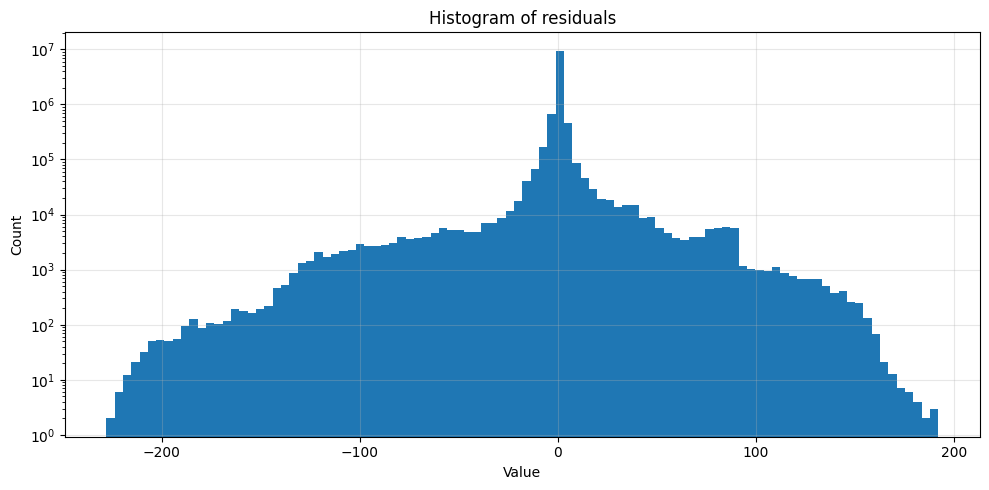

min=-228.000000, max=192.000000, mean=0.032141, std=10.159962


tensor[49, 360, 640] n=11289600 (43Mb) x∈[-228.000, 192.000] μ=0.032 σ=10.160

In [27]:
# Histogram of all values in the loaded volume
residuals = (volume[:, :, 1:] - volume[:, :, :-1])
residuals = residuals.permute(2, 0, 1)  # (D-1, H, W)

plt.figure(figsize=(10, 5))
# histogram in log metric to better visualize the distribution of values
plt.hist(residuals.ravel(), bins=100, log=True)

plt.title('Histogram of residuals')
plt.xlabel('Value')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"min={residuals.min():.6f}, max={residuals.max():.6f}, mean={residuals.mean():.6f}, std={residuals.std():.6f}")
residuals

## Metric Helpers

In [28]:
def psnr(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    mse = float(np.mean((np.clip(pred, tgt.min(), tgt.max()) - tgt) ** 2))
    return 10 * math.log10(dr ** 2 / (mse + 1e-10))

def ssim(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    return float(_skimage_ssim(tgt, np.clip(pred, tgt.min(), tgt.max()), data_range=dr))

print("Metric helpers ready")

Metric helpers ready


## 1. Cumulative Re-Encoding Residual Compression

**Algorithm:**

Let the list `S` start with the normalized `f_0`.  
For each iteration `i = 0, 1, ..., N−2`:

1. Re-encode every element of `S` into a single HEVC stream.
2. Close the stream, decode the **last frame** → get the decoded signal `ŝ_i`.
3. Denormalize `ŝ_i` to obtain the raw decoded signal.
4. Update the running reconstruction `f̂_i`:
   - If `i = 0`: `f̂_0 = ŝ_i` (decoded `f_0`)
   - If `i > 0`: `f̂_i = f̂_{i−1} − ŝ_i` (decoded residual `r̂_i`)
5. Compute `r_{i+1} = f̂_i − f_{i+1}`, normalize, and **append to `S`**.

After the loop, the last HEVC file contains the full sequence.
**Final reconstruction** decodes that file and cumulates residuals from `f_0`.

In [36]:
CQ_CUMULATIVE = 90   # HEVC quality for residual encoding

cumul_outdir = Path('cumulative_reenc_output')
cumul_outdir.mkdir(parents=True, exist_ok=True)

raw_bytes_per_frame = H * W * 2  # int16 baseline

params_cumul = EncoderParams(
    cq_hw=CQ_CUMULATIVE,
    preset_sw="medium",
    fps=30,
    force_software=False,
)

# ── Accumulator state ────────────────────────────────────────────────────
signals_normalized: list[torch.Tensor] = []  # [0,1] float (H,W) tensors
norms: list[tuple[float, float]] = []         # (fmin, fmax) per signal

# ── Save f_0 losslessly as .npy ───────────────────────────────────────────
f0 = volume[:, :, 0]
fmin0, fmax0 = float(f0.min()), float(f0.max())
f0_normalized = ((f0 - fmin0) / (fmax0 - fmin0 + 1e-8)).float()
norms.append((fmin0, fmax0))

f0_path = cumul_outdir / "f0_frame.npy"
np.save(str(f0_path), f0_normalized.cpu().numpy())
print(f"f_0 saved losslessly: {f0_path.name}  ({f0_path.stat().st_size / 1e3:.1f} kB)")

# f_0 is lossless → use it directly as the initial reconstruction
f_hat = f0.float()

# residuals list: r_1, r_2, ..., r_{N-1} (no f_0 ever enters the HEVC stream)
residuals_normalized: list[torch.Tensor] = []

print(f"\nCumulative re-encoding: {N_FRAMES} frames, cq_residuals={CQ_CUMULATIVE}")
print(f"This runs {N_FRAMES - 1} encode/decode iterations (list grows by 1 each step).")
print(f"{'─'*60}")

for i in range(N_FRAMES - 1):
    # ── Step 1: Compute r_{i+1} = f̂_i − f_{i+1} ────────────────────────
    f_next = volume[:, :, i + 1]
    r_next = f_hat - f_next

    # r_next[r_next.abs() < 0.005] = 0.0  # zero-out very small residuals to reduce noise in the HEVC encoding

    rmin, rmax = float(r_next.min()), float(r_next.max())
    norms.append((rmin, rmax))
    # residuals_normalized.append(torch.log(1 + (r_next - rmin) / (rmax - rmin + 1e-8)).float())
    residuals_normalized.append(((r_next - rmin) / (rmax - rmin + 1e-8)).float())

    # ── Step 2: Re-encode all residuals so far (f_0 never included) ──────
    streamer = HevcGray10Streamer(
        cumul_outdir,
        segment_prefix=f"cumul_step_{i:04d}",
        params=params_cumul,
    )
    with streamer.start_segment():
        for sig in residuals_normalized:
            streamer.append_frame(sig)

    seg_path = streamer.segments[0]

    # ── Step 3: Decode the last residual → update f̂ ──────────────────────
    decoded_all = decode_hevc_grayscale_10bit(str(seg_path))  # (i+1, H, W)
    last_dec = decoded_all[-1].float()

    # last_dec = torch.exp(last_dec) - 1  # inverse of the log(1 + x) normalization


    fmin_last, fmax_last = norms[-1]
    raw_last = last_dec * (fmax_last - fmin_last + 1e-8) + fmin_last

    f_hat = f_hat - raw_last   # f̂_{i+1} = f̂_i − r̂_{i+1}

    seg_kb = seg_path.stat().st_size / 1e3
    if i < 5 or i == N_FRAMES - 2 or i % 20 == 0:
        print(f"  Step {i:3d} | list_len={len(residuals_normalized):3d} | "
              f"seg={seg_kb:.1f} kB | residual range [{rmin:.5f}, {rmax:.5f}]")

print(f"\n✅  Loop complete. {len(residuals_normalized)} residuals computed.")

# ── Final encode: all residuals in one uniform HEVC stream ───────────────
print(f"\nEncoding {len(residuals_normalized)} residuals at cq={CQ_CUMULATIVE} ...")
final_streamer = HevcGray10Streamer(
    cumul_outdir,
    segment_prefix="cumul_final",
    params=params_cumul,
)
with final_streamer.start_segment():
    for sig in residuals_normalized:
        final_streamer.append_frame(sig)

last_seg_path = final_streamer.segments[0]
print(f"   Residuals HEVC: {last_seg_path.name}  ({last_seg_path.stat().st_size/1e6:.3f} MB)")


f_0 saved losslessly: f0_frame.npy  (921.7 kB)

Cumulative re-encoding: 50 frames, cq_residuals=90
This runs 49 encode/decode iterations (list grows by 1 each step).
────────────────────────────────────────────────────────────
  Step   0 | list_len=  1 | seg=20.4 kB | residual range [-43.00000, 64.00000]
  Step   1 | list_len=  2 | seg=42.0 kB | residual range [-47.18347, 60.72466]
  Step   2 | list_len=  3 | seg=60.1 kB | residual range [-47.34961, 57.83487]
  Step   3 | list_len=  4 | seg=73.9 kB | residual range [-53.43567, 59.03189]
  Step   4 | list_len=  5 | seg=89.4 kB | residual range [-50.97333, 59.38354]
  Step  20 | list_len= 21 | seg=373.7 kB | residual range [-153.60381, 135.67354]
  Step  40 | list_len= 41 | seg=773.5 kB | residual range [-135.50525, 151.58093]
  Step  48 | list_len= 49 | seg=945.6 kB | residual range [-123.94189, 123.47952]

✅  Loop complete. 49 residuals computed.

Encoding 49 residuals at cq=90 ...
   Residuals HEVC: cumul_final_0000.mov  (0.946 MB)


In [37]:
# ── Final reconstruction ─────────────────────────────────────────────────
print("Loading f_0 and decoding residuals HEVC ...")
f0_loaded = torch.from_numpy(np.load(str(f0_path))).float()  # (H, W) in [0,1]
decoded_residuals = decode_hevc_grayscale_10bit(str(last_seg_path))  # (N_FRAMES-1, H, W)

# decoded_residuals = torch.exp(decoded_residuals) - 1  # inverse of the log(1 + x) normalization

# Denormalize f_0 (lossless — loaded from .npy)
fmin0_, fmax0_ = norms[0]
cumul_recon = torch.zeros(N_FRAMES, H, W)
cumul_recon[0] = f0_loaded * (fmax0_ - fmin0_ + 1e-8) + fmin0_

# Cumulate decoded residuals r_1..r_{N-1}
# norms[j] corresponds to decoded_residuals[j-1] (norms[0] = f_0)
for j in range(1, N_FRAMES):
    fmin_j, fmax_j = norms[j]
    denormed_j = decoded_residuals[j - 1].float() * (fmax_j - fmin_j + 1e-8) + fmin_j
    cumul_recon[j] = cumul_recon[j - 1] - denormed_j

# ── Storage ──────────────────────────────────────────────────────────────
final_hevc_bytes = last_seg_path.stat().st_size
f0_bytes         = f0_path.stat().st_size
norm_meta_bytes  = N_FRAMES * 2 * 4          # 2 float32 per frame
total_cumul_bytes = final_hevc_bytes + f0_bytes + norm_meta_bytes
raw_total = N_FRAMES * raw_bytes_per_frame
cr_cumul  = raw_total / total_cumul_bytes

# ── Per-frame metrics ─────────────────────────────────────────────────────
cumul_metrics = []
for fi in range(N_FRAMES):
    rec_np = cumul_recon[fi].cpu().numpy()
    tgt_np = volume[:, :, fi].cpu().numpy()
    cumul_metrics.append({"psnr": psnr(rec_np, tgt_np), "ssim": ssim(rec_np, tgt_np)})

avg_cumul_psnr     = float(np.mean([m["psnr"] for m in cumul_metrics]))
avg_cumul_ssim     = float(np.mean([m["ssim"] for m in cumul_metrics]))
avg_cumul_psnr_no0 = float(np.mean([m["psnr"] for m in cumul_metrics[1:]]))
avg_cumul_ssim_no0 = float(np.mean([m["ssim"] for m in cumul_metrics[1:]]))

print(f"\n{'─'*60}")
print(f"  Residuals HEVC:  {final_hevc_bytes/1e6:.3f} MB")
print(f"  f_0 (lossless):  {f0_bytes/1e3:.1f} kB")
print(f"  Norm metadata:   {norm_meta_bytes} B")
print(f"  Total:           {total_cumul_bytes/1e6:.3f} MB")
print(f"  Raw (int16):     {raw_total/1e6:.3f} MB")
print(f"  CR:              {cr_cumul:.2f}×")
print(f"  Avg PSNR (all):       {avg_cumul_psnr:.2f} dB")
print(f"  Avg PSNR (excl. f0):  {avg_cumul_psnr_no0:.2f} dB")
print(f"  Avg SSIM (all):       {avg_cumul_ssim:.4f}")
print(f"  Avg SSIM (excl. f0):  {avg_cumul_ssim_no0:.4f}")
print(f"{'─'*60}")


Loading f_0 and decoding residuals HEVC ...

────────────────────────────────────────────────────────────
  Residuals HEVC:  0.946 MB
  f_0 (lossless):  921.7 kB
  Norm metadata:   400 B
  Total:           1.868 MB
  Raw (int16):     23.040 MB
  CR:              12.34×
  Avg PSNR (all):       52.92 dB
  Avg PSNR (excl. f0):  51.01 dB
  Avg SSIM (all):       0.9934
  Avg SSIM (excl. f0):  0.9933
────────────────────────────────────────────────────────────


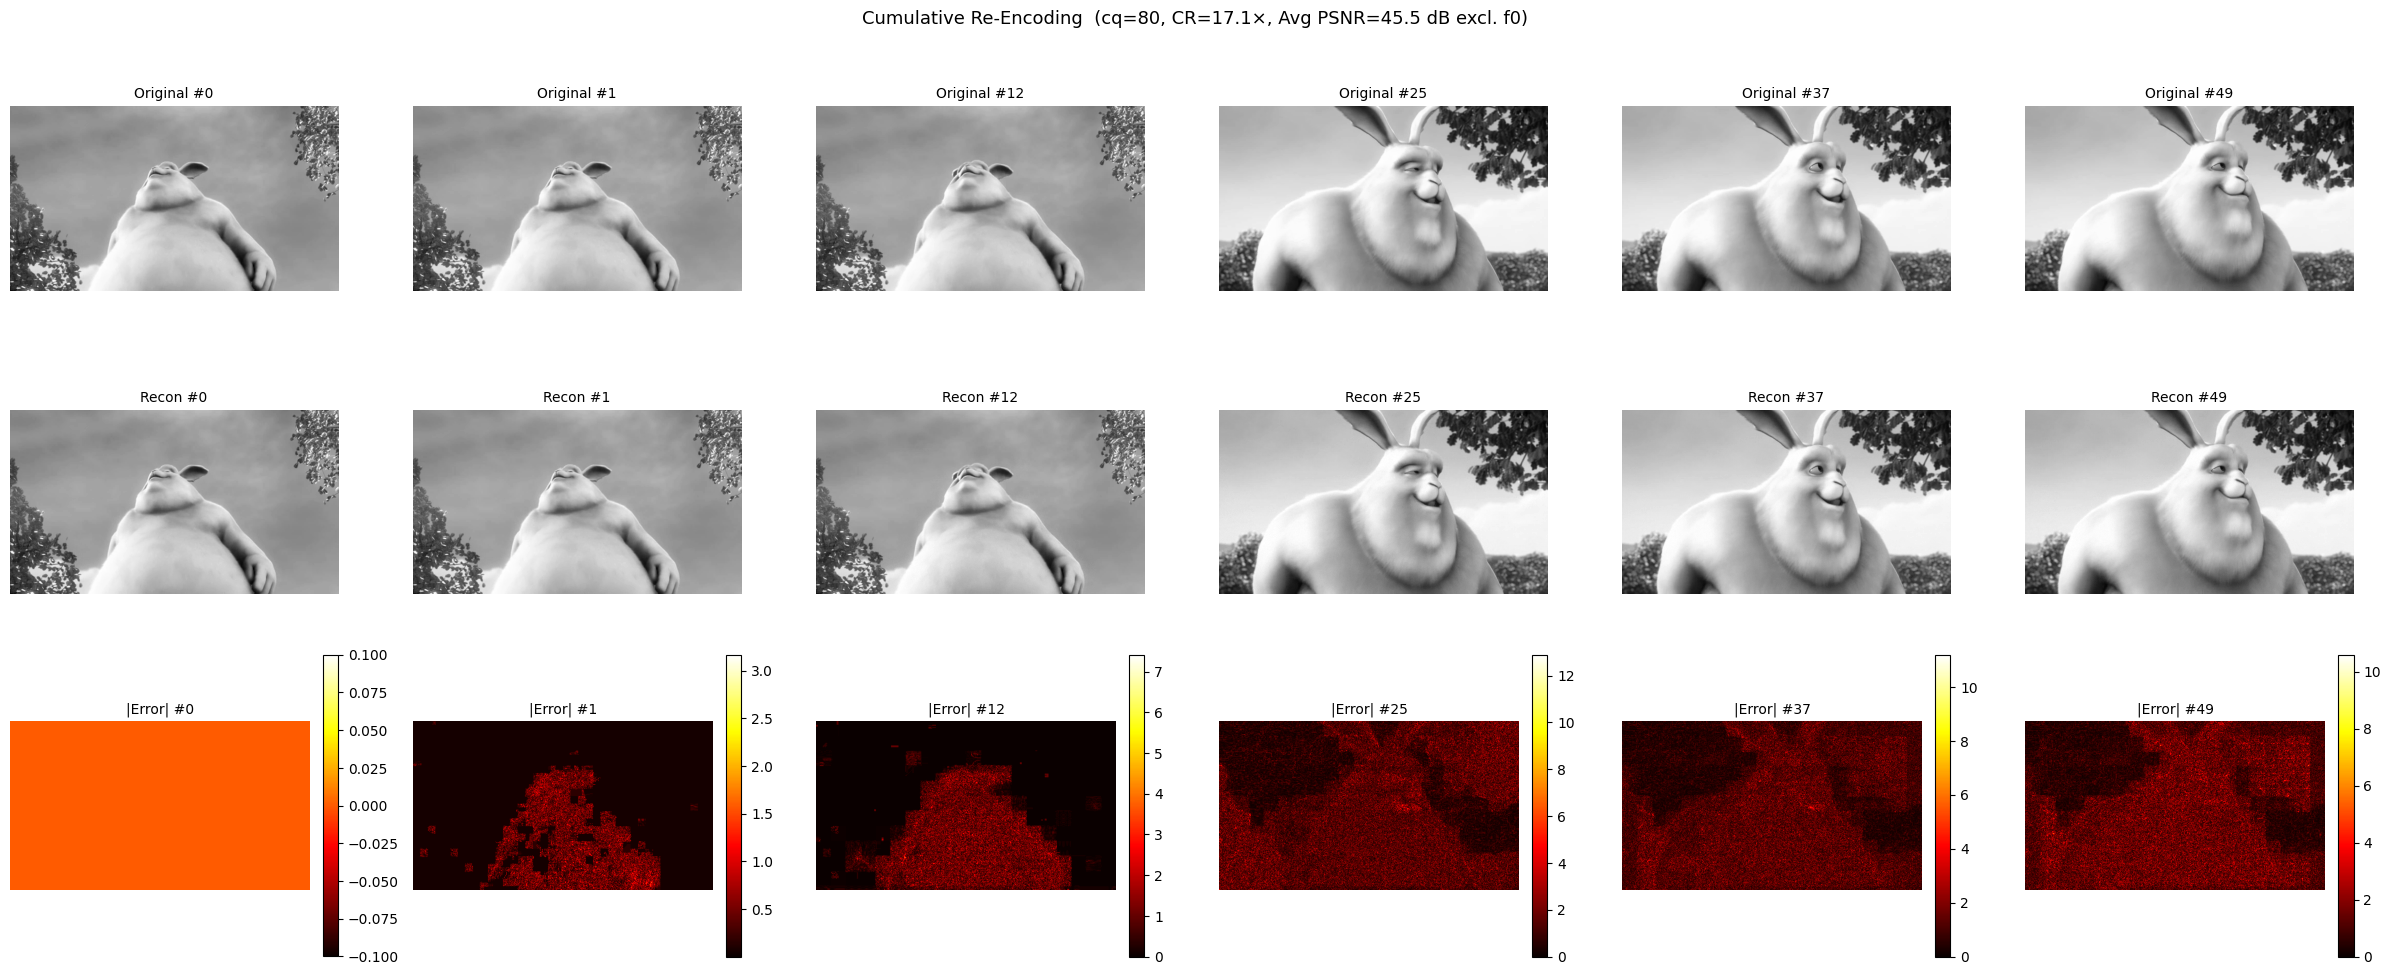

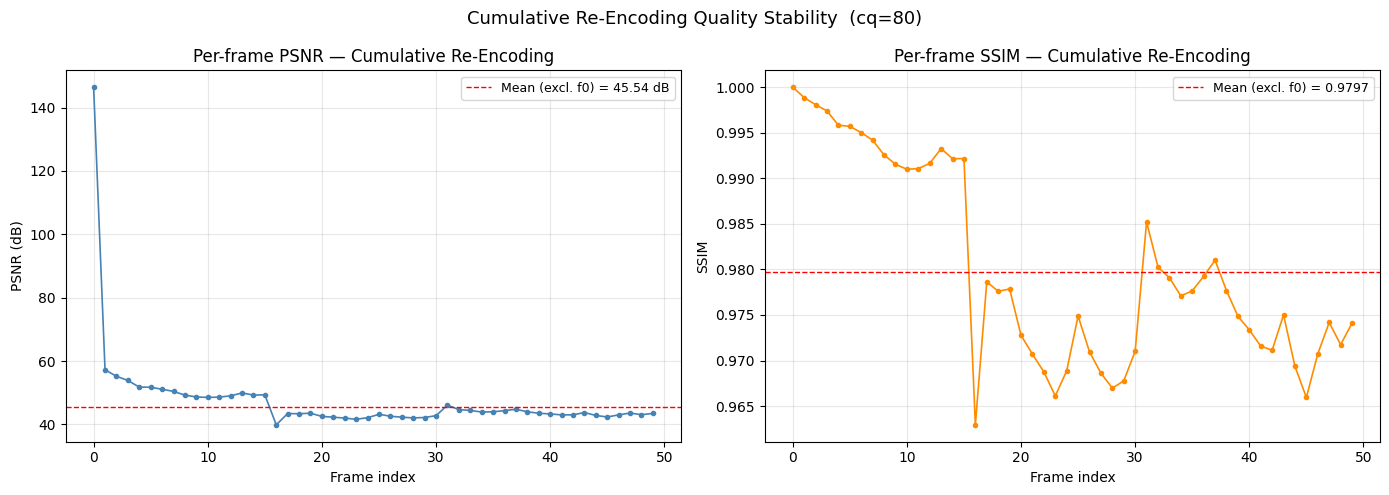

In [31]:
# ── Visualise a sample of reconstructed frames vs originals ─────────────
show_idxs = sorted(set([0, 1, N_FRAMES // 4, N_FRAMES // 2, 3 * N_FRAMES // 4, N_FRAMES - 1]))

fig, axes = plt.subplots(3, len(show_idxs), figsize=(4 * len(show_idxs), 10))

for col, fi in enumerate(show_idxs):
    orig_f = volume[:, :, fi].cpu().numpy()
    rec_f  = cumul_recon[fi].cpu().numpy()
    diff_f = np.abs(orig_f - rec_f)
    vmin, vmax = orig_f.min(), orig_f.max()

    axes[0, col].imshow(orig_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'Original #{fi}', fontsize=10); axes[0, col].axis('off')

    axes[1, col].imshow(rec_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'Recon #{fi}', fontsize=10); axes[1, col].axis('off')

    im = axes[2, col].imshow(diff_f, cmap='hot')
    axes[2, col].set_title(f'|Error| #{fi}', fontsize=10); axes[2, col].axis('off')
    plt.colorbar(im, ax=axes[2, col], fraction=0.046, pad=0.04)

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstructed', fontsize=11)
axes[2, 0].set_ylabel('Abs Error', fontsize=11)

plt.suptitle(f'Cumulative Re-Encoding  (cq={CQ_CUMULATIVE}, CR={cr_cumul:.1f}×, '
             f'Avg PSNR={avg_cumul_psnr_no0:.1f} dB excl. f0)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-frame PSNR / SSIM ────────────────────────────────────────────────
cumul_psnrs = [m["psnr"] for m in cumul_metrics]
cumul_ssims = [m["ssim"] for m in cumul_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(N_FRAMES), cumul_psnrs, 'o-', color='steelblue', linewidth=1.2, markersize=3)
axes[0].axhline(avg_cumul_psnr_no0, color='red', linestyle='--', linewidth=1,
                label=f'Mean (excl. f0) = {avg_cumul_psnr_no0:.2f} dB')
axes[0].set_xlabel('Frame index'); axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Per-frame PSNR — Cumulative Re-Encoding')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(N_FRAMES), cumul_ssims, 'o-', color='darkorange', linewidth=1.2, markersize=3)
axes[1].axhline(avg_cumul_ssim_no0, color='red', linestyle='--', linewidth=1,
                label=f'Mean (excl. f0) = {avg_cumul_ssim_no0:.4f}')
axes[1].set_xlabel('Frame index'); axes[1].set_ylabel('SSIM')
axes[1].set_title('Per-frame SSIM — Cumulative Re-Encoding')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Cumulative Re-Encoding Quality Stability  (cq={CQ_CUMULATIVE})', fontsize=13)
plt.tight_layout()
plt.show()

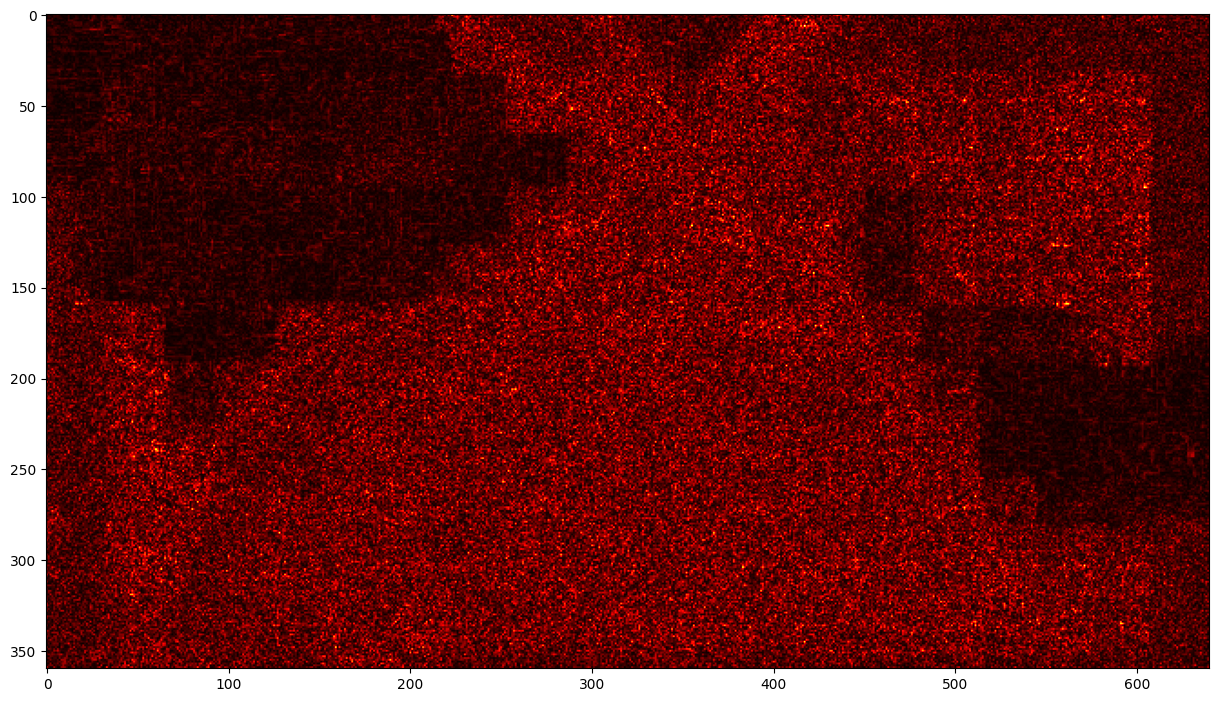

In [32]:
plt.figure(figsize=(15, 15))
plt.imshow(diff_f, cmap='hot')

## 2. Baseline — Direct HEVC Encoding of Raw Frames

Encode the original frame sequence `f_0, f_1, ..., f_{N-1}` directly with `HevcGray10Streamer`
at **cq = 100** and **cq = 99** (mirrors the §4 quality sweep in `CompressionComparison`).

Each frame is independently per-frame normalised to `[0, 1]` before encoding, with
`(min, max)` metadata stored for inversion — the same convention used throughout this notebook.

In [33]:
BASELINE_QUALITY_LEVELS = [
    {"label": "VHQ (cq=100)", "cq_hw": 100},
    {"label": "HQ  (cq=99)",  "cq_hw": 99},
]

baseline_outdir = Path('baseline_hevc_output')
baseline_outdir.mkdir(parents=True, exist_ok=True)

# Pre-compute per-frame normalisation for the raw frames
frame_norms_bl: list[tuple[float, float]] = []
frames_normed_bl: list[torch.Tensor] = []
for fi in range(N_FRAMES):
    f = volume[:, :, fi]
    fmin, fmax = float(f.min()), float(f.max())
    frame_norms_bl.append((fmin, fmax))
    frames_normed_bl.append(((f - fmin) / (fmax - fmin + 1e-8)).float())

baseline_results: dict = {}

for ql in BASELINE_QUALITY_LEVELS:
    label  = ql["label"]
    cq     = ql["cq_hw"]
    print(f"\n{'═'*60}")
    print(f"  Baseline: {label}")
    print(f"{'═'*60}")

    params_bl = EncoderParams(
        cq_hw=cq,
        preset_sw="medium",
        fps=30,
        force_software=False,
    )

    streamer_bl = HevcGray10Streamer(
        baseline_outdir,
        segment_prefix=f"baseline_cq{cq}",
        params=params_bl,
    )
    with streamer_bl.start_segment():
        for fn in frames_normed_bl:
            streamer_bl.append_frame(fn)

    seg_path_bl = streamer_bl.segments[0]
    hevc_bytes_bl = seg_path_bl.stat().st_size
    norm_meta_bl  = N_FRAMES * 2 * 4
    total_bl      = hevc_bytes_bl + norm_meta_bl
    cr_bl         = raw_total / total_bl

    print(f"  HEVC file:     {hevc_bytes_bl/1e6:.3f} MB")
    print(f"  Total:         {total_bl/1e6:.3f} MB")
    print(f"  CR:            {cr_bl:.2f}×")

    # Decode and reconstruct
    decoded_bl = decode_hevc_grayscale_10bit(str(seg_path_bl))  # (N_FRAMES, H, W)
    recon_bl   = torch.zeros(N_FRAMES, H, W)
    for fi in range(N_FRAMES):
        fmin_fi, fmax_fi = frame_norms_bl[fi]
        recon_bl[fi] = decoded_bl[fi].float() * (fmax_fi - fmin_fi + 1e-8) + fmin_fi

    # Per-frame metrics
    metrics_bl = []
    for fi in range(N_FRAMES):
        rec_np = recon_bl[fi].cpu().numpy()
        tgt_np = volume[:, :, fi].cpu().numpy()
        metrics_bl.append({"psnr": psnr(rec_np, tgt_np), "ssim": ssim(rec_np, tgt_np)})

    avg_psnr_bl     = float(np.mean([m["psnr"] for m in metrics_bl]))
    avg_ssim_bl     = float(np.mean([m["ssim"] for m in metrics_bl]))
    avg_psnr_bl_no0 = float(np.mean([m["psnr"] for m in metrics_bl[1:]]))
    avg_ssim_bl_no0 = float(np.mean([m["ssim"] for m in metrics_bl[1:]]))

    print(f"  Avg PSNR (all):       {avg_psnr_bl:.2f} dB")
    print(f"  Avg PSNR (excl. f0):  {avg_psnr_bl_no0:.2f} dB")
    print(f"  Avg SSIM (all):       {avg_ssim_bl:.4f}")
    print(f"  Avg SSIM (excl. f0):  {avg_ssim_bl_no0:.4f}")

    baseline_results[label] = {
        "cq":           cq,
        "recon":        recon_bl.clone(),
        "metrics":      metrics_bl,
        "total_bytes":  total_bl,
        "hevc_bytes":   hevc_bytes_bl,
        "cr":           cr_bl,
        "avg_psnr":     avg_psnr_bl,
        "avg_ssim":     avg_ssim_bl,
        "avg_psnr_no0": avg_psnr_bl_no0,
        "avg_ssim_bl_no0": avg_ssim_bl_no0,
    }

print("\n✅  Baseline encoding complete")


════════════════════════════════════════════════════════════
  Baseline: VHQ (cq=100)
════════════════════════════════════════════════════════════
  HEVC file:     3.404 MB
  Total:         3.405 MB
  CR:            6.77×
  Avg PSNR (all):       69.64 dB
  Avg PSNR (excl. f0):  69.64 dB
  Avg SSIM (all):       0.9999
  Avg SSIM (excl. f0):  0.9999

════════════════════════════════════════════════════════════
  Baseline: HQ  (cq=99)
════════════════════════════════════════════════════════════
  HEVC file:     1.595 MB
  Total:         1.595 MB
  CR:            14.44×
  Avg PSNR (all):       60.60 dB
  Avg PSNR (excl. f0):  60.58 dB
  Avg SSIM (all):       0.9995
  Avg SSIM (excl. f0):  0.9995

✅  Baseline encoding complete


## 3. Comparison: Cumulative Re-Encoding vs Baselines

In [38]:
# ── Summary table ────────────────────────────────────────────────────────
bl_labels = list(baseline_results.keys())
cumul_label = f"Cumulative (cq={CQ_CUMULATIVE})"

all_labels   = bl_labels + [cumul_label]
all_psnr_no0 = [baseline_results[l]["avg_psnr_no0"] for l in bl_labels] + [avg_cumul_psnr_no0]
all_ssim_no0 = [baseline_results[l]["avg_ssim_bl_no0"] for l in bl_labels] + [avg_cumul_ssim_no0]
all_cr       = [baseline_results[l]["cr"] for l in bl_labels] + [cr_cumul]
all_mb       = [baseline_results[l]["total_bytes"]/1e6 for l in bl_labels] + [total_cumul_bytes/1e6]

col_w = 26
print(f"{'Method':30} {'Total (MB)':>10} {'CR':>8} {'PSNR no f0':>12} {'SSIM no f0':>12}")
print("─" * 76)
for lbl, mb, cr_, p, s in zip(all_labels, all_mb, all_cr, all_psnr_no0, all_ssim_no0):
    print(f"{lbl:30} {mb:>10.3f} {cr_:>7.2f}× {p:>12.2f} {s:>12.4f}")
print("─" * 76)
print(f"  Raw (int16): {raw_total/1e6:.3f} MB")

Method                         Total (MB)       CR   PSNR no f0   SSIM no f0
────────────────────────────────────────────────────────────────────────────
VHQ (cq=100)                        3.405    6.77×        69.64       0.9999
HQ  (cq=99)                         1.595   14.44×        60.58       0.9995
Cumulative (cq=90)                  1.868   12.34×        51.01       0.9933
────────────────────────────────────────────────────────────────────────────
  Raw (int16): 23.040 MB


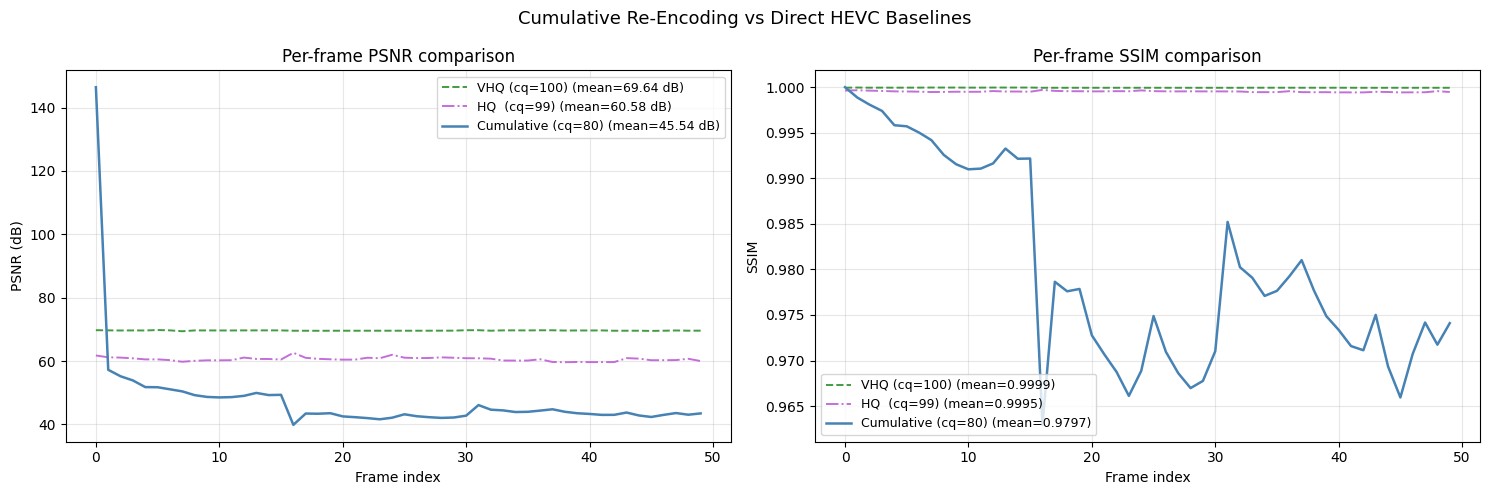

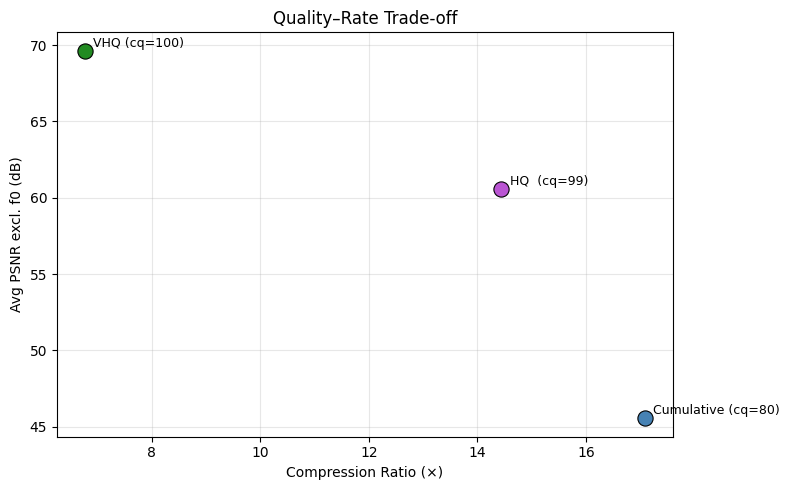

In [35]:
# ── Per-frame PSNR overlay: all methods ─────────────────────────────────
colors = {"VHQ (cq=100)": "forestgreen", "HQ  (cq=99)": "mediumorchid",
          cumul_label: "steelblue"}
linestyles = {"VHQ (cq=100)": "--", "HQ  (cq=99)": "-.", cumul_label: "-"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for lbl in bl_labels:
    res = baseline_results[lbl]
    psnrs_ = [m["psnr"] for m in res["metrics"]]
    ssims_ = [m["ssim"] for m in res["metrics"]]
    axes[0].plot(range(N_FRAMES), psnrs_, linestyles[lbl], color=colors[lbl],
                 linewidth=1.4, markersize=0, label=f'{lbl} (mean={res["avg_psnr_no0"]:.2f} dB)',
                 alpha=0.85)
    axes[1].plot(range(N_FRAMES), ssims_, linestyles[lbl], color=colors[lbl],
                 linewidth=1.4, markersize=0, label=f'{lbl} (mean={res["avg_ssim_bl_no0"]:.4f})',
                 alpha=0.85)

axes[0].plot(range(N_FRAMES), cumul_psnrs, '-', color=colors[cumul_label],
             linewidth=1.8, markersize=0,
             label=f'{cumul_label} (mean={avg_cumul_psnr_no0:.2f} dB)')
axes[1].plot(range(N_FRAMES), cumul_ssims, '-', color=colors[cumul_label],
             linewidth=1.8, markersize=0,
             label=f'{cumul_label} (mean={avg_cumul_ssim_no0:.4f})')

for ax, ylabel, title in zip(
    axes,
    ["PSNR (dB)", "SSIM"],
    ["Per-frame PSNR comparison", "Per-frame SSIM comparison"],
):
    ax.set_xlabel("Frame index")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Cumulative Re-Encoding vs Direct HEVC Baselines", fontsize=13)
plt.tight_layout()
plt.show()

# ── CR vs PSNR scatter ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for lbl, cr_, p in zip(all_labels, all_cr, all_psnr_no0):
    c = colors[lbl] if lbl in colors else "gray"
    ax.scatter(cr_, p, s=120, color=c, zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(lbl, (cr_, p), textcoords="offset points", xytext=(6, 3), fontsize=9)

ax.set_xlabel("Compression Ratio (×)")
ax.set_ylabel("Avg PSNR excl. f0 (dB)")
ax.set_title("Quality–Rate Trade-off")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()